In [1]:
# ============================================================================
# NOTEBOOK 01 — ANÁLISIS EXPLORATORIO DE LA DEMANDA ELÉCTRICA
# ============================================================================
# Objetivo: entender los patrones temporales de la serie antes de modelar.
# Salidas: figuras y estadísticos que justifican las decisiones del LSTM.
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120

# Cargar dataset
df = pd.read_csv('../data/demanda_clean.csv', parse_dates=['timestamp'])
print(f"Filas: {len(df):,}")
print(f"Columnas: {list(df.columns)}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
df.head()

Filas: 29,183
Columnas: ['timestamp', 'demanda_mw', 'hora', 'dia_sem', 'mes', 'dia_anio', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'es_finde', 'es_festivo']
Rango: 2022-12-31 23:00:00  →  2026-04-30 21:00:00


,timestamp,demanda_mw,hora,dia_sem,mes,dia_anio,hora_sin,hora_cos,dia_sin,dia_cos,mes_sin,mes_cos,es_finde,es_festivo
0,2022-12-31 23:00:00,19872.637,0,6,1,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,1,1
1,2023-01-01 00:00:00,19198.718,1,6,1,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,1,1
2,2023-01-01 01:00:00,18099.597,2,6,1,1,0.500000,0.866025,-0.781831,0.62349,0.0,1.0,1,1
3,2023-01-01 02:00:00,17142.238,3,6,1,1,0.707107,0.707107,-0.781831,0.62349,0.0,1.0,1,1
4,2023-01-01 03:00:00,16539.586,4,6,1,1,0.866025,0.500000,-0.781831,0.62349,0.0,1.0,1,1


In [3]:
print("Estadísticas de la demanda (MW):")
print(df['demanda_mw'].describe())

print(f"\nTamaño del dataset:")
print(f"  - Total horas: {len(df):,}")
print(f"  - Total días:  {len(df) // 24:,}")
print(f"  - Total años:  {len(df) / 8760:.2f}")

Estadísticas de la demanda (MW):
count    29183.000000
mean     26932.551444
std       4308.004255
min      16272.179000
25%      23402.813000
50%      26960.931000
75%      29985.919000
max      41725.907000
Name: demanda_mw, dtype: float64

Tamaño del dataset:
  - Total horas: 29,183
  - Total días:  1,215
  - Total años:  3.33


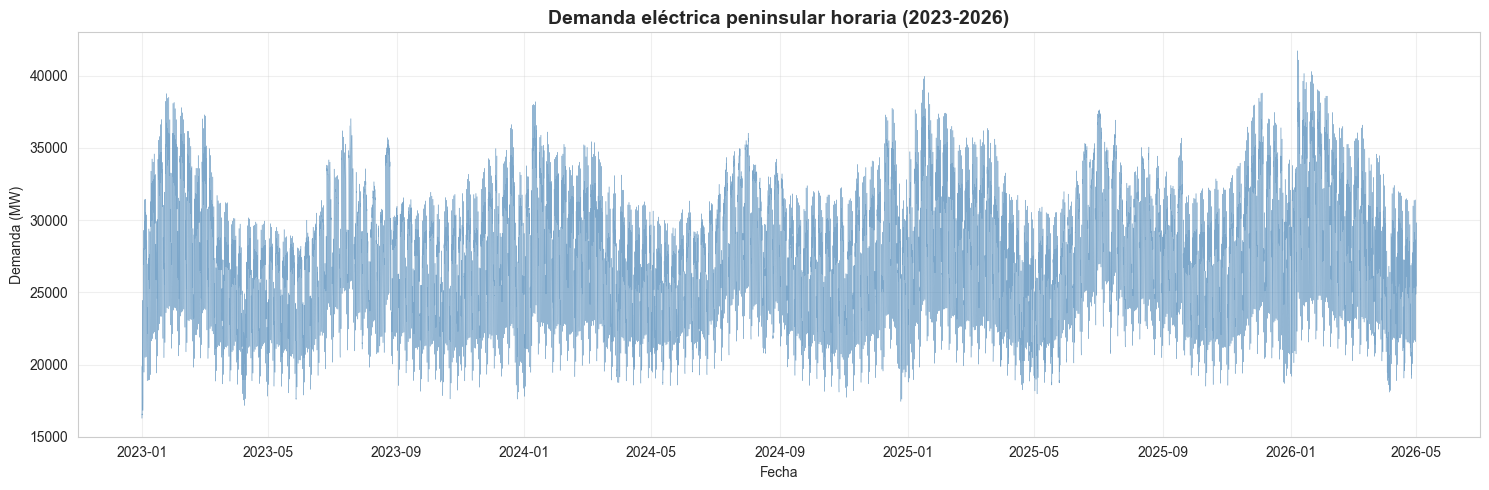

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['timestamp'], df['demanda_mw'], linewidth=0.3, alpha=0.7, color='steelblue')
ax.set_title('Demanda eléctrica peninsular horaria (2023-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MW)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/01_serie_completa.png', bbox_inches='tight')
plt.show()

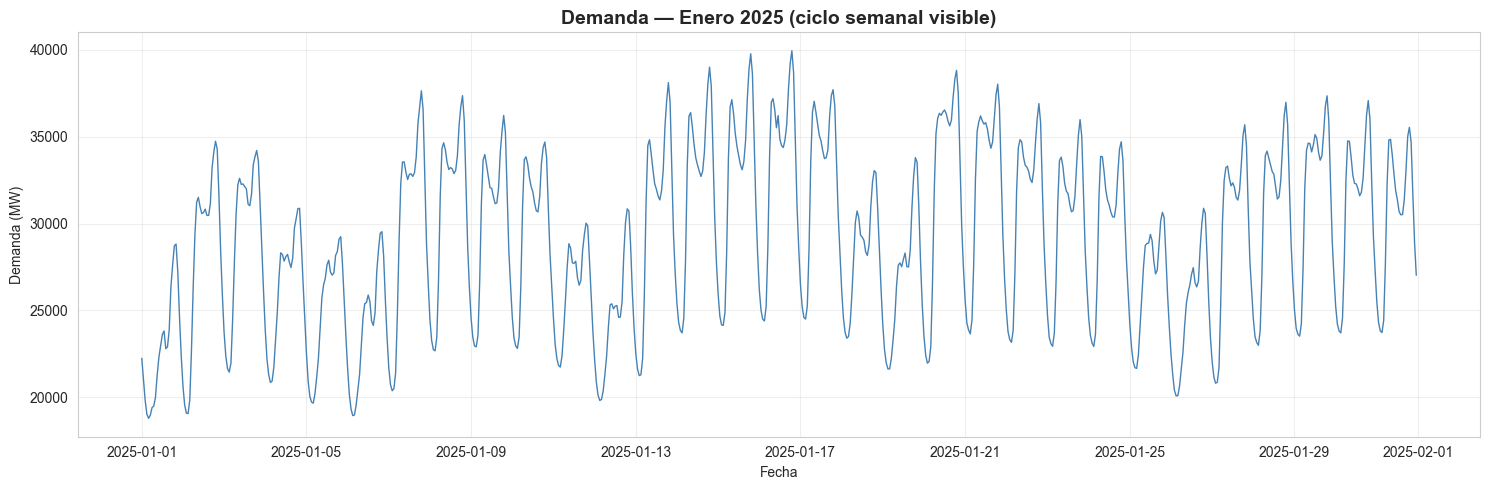

In [8]:
# Cogemos un mes representativo: enero 2025
mascara = (df['timestamp'] >= '2025-01-01') & (df['timestamp'] < '2025-02-01')
df_mes = df[mascara]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_mes['timestamp'], df_mes['demanda_mw'], linewidth=1, color='steelblue')
ax.set_title('Demanda — Enero 2025 (ciclo semanal visible)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MW)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/02_serie_mes.png', bbox_inches='tight')
plt.show()

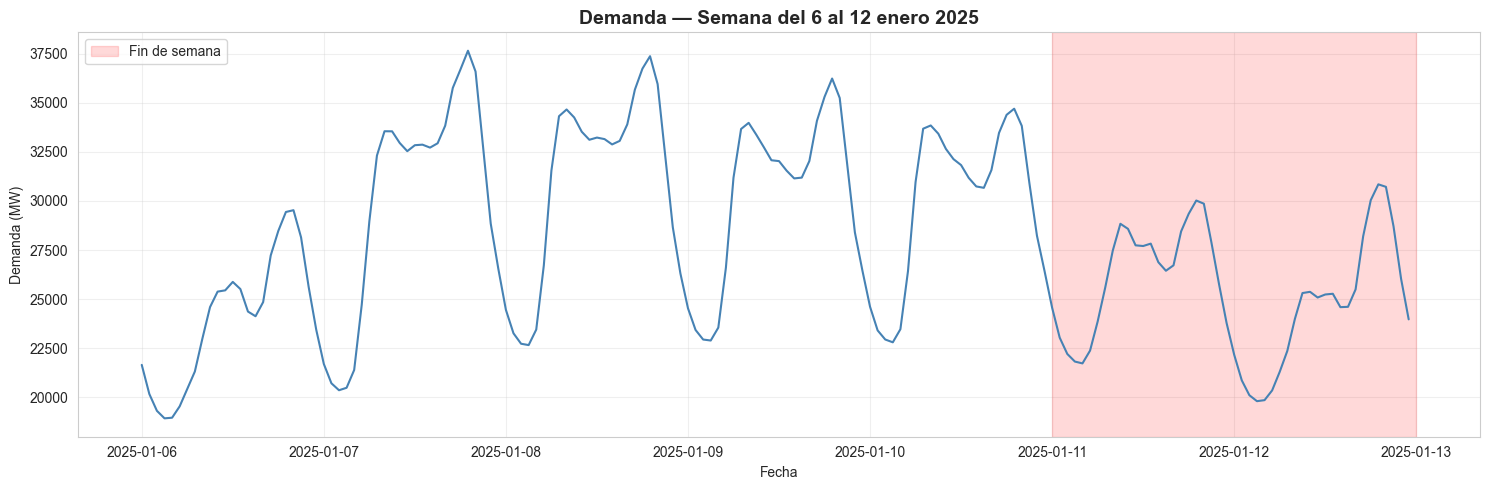

In [ ]:
# Primera semana de enero 2025 (lunes a domingo)
mascara = (df['timestamp'] >= '2025-01-06') & (df['timestamp'] < '2025-01-13')
df_sem = df[mascara]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_sem['timestamp'], df_sem['demanda_mw'], linewidth=1.5, color='steelblue')
ax.set_title('Demanda — Semana del 6 al 12 enero 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MW)')
ax.grid(True, alpha=0.3)
ax.axvspan('2025-01-11', '2025-01-13', alpha=0.15, color='red', label='Fin de semana')
ax.legend()
plt.tight_layout()
plt.savefig('../../docs/capturas/03_serie_semana.png', bbox_inches='tight')
plt.show()

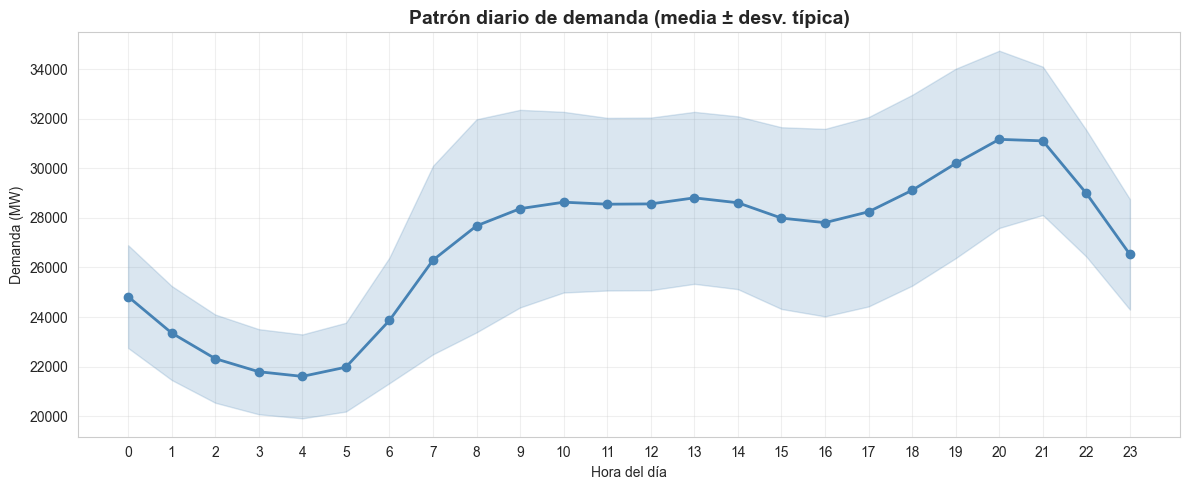

In [10]:
# Demanda media por hora del día
fig, ax = plt.subplots(figsize=(12, 5))
horarios = df.groupby('hora')['demanda_mw'].agg(['mean', 'std'])
ax.plot(horarios.index, horarios['mean'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(horarios.index,
                horarios['mean'] - horarios['std'],
                horarios['mean'] + horarios['std'],
                alpha=0.2, color='steelblue')
ax.set_title('Patrón diario de demanda (media ± desv. típica)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Demanda (MW)')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/04_patron_diario.png', bbox_inches='tight')
plt.show()

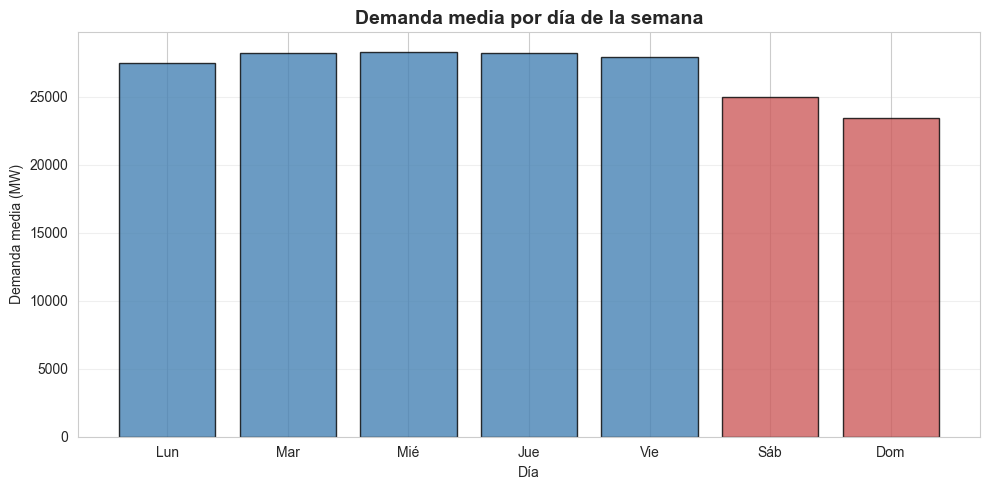


Demanda media laboral: 28026 MW
Demanda media finde:   24194 MW
Diferencia:            3832 MW


In [11]:
# Demanda media por día de la semana
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
fig, ax = plt.subplots(figsize=(10, 5))
medias = df.groupby('dia_sem')['demanda_mw'].mean()
colors = ['steelblue']*5 + ['indianred']*2
ax.bar(dias, medias.values, color=colors, alpha=0.8, edgecolor='black')
ax.set_title('Demanda media por día de la semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día')
ax.set_ylabel('Demanda media (MW)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../../docs/capturas/05_patron_semanal.png', bbox_inches='tight')
plt.show()

print(f"\nDemanda media laboral: {df[df['es_finde']==0]['demanda_mw'].mean():.0f} MW")
print(f"Demanda media finde:   {df[df['es_finde']==1]['demanda_mw'].mean():.0f} MW")
print(f"Diferencia:            {df[df['es_finde']==0]['demanda_mw'].mean() - df[df['es_finde']==1]['demanda_mw'].mean():.0f} MW")

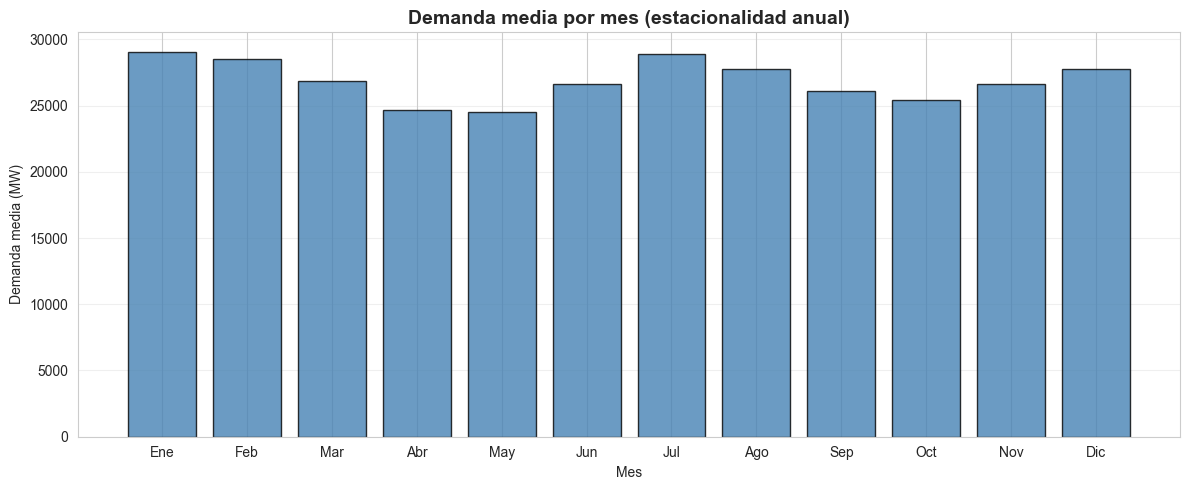

In [12]:
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
fig, ax = plt.subplots(figsize=(12, 5))
medias_mes = df.groupby('mes')['demanda_mw'].mean()
ax.bar(meses, medias_mes.values, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_title('Demanda media por mes (estacionalidad anual)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Demanda media (MW)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../../docs/capturas/06_patron_anual.png', bbox_inches='tight')
plt.show()

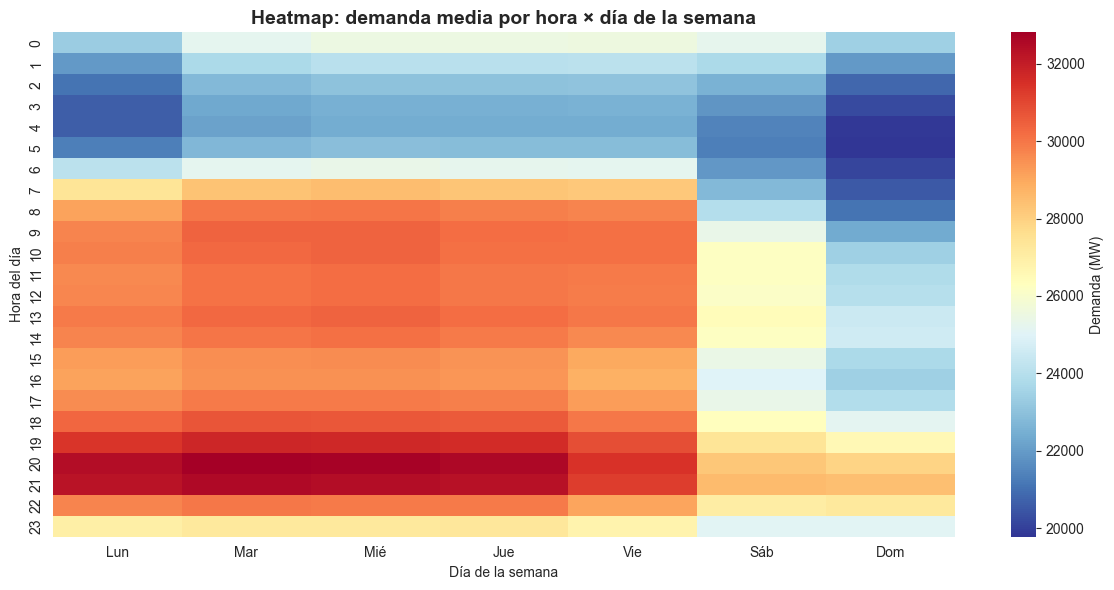

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
heat = df.pivot_table(values='demanda_mw', index='hora', columns='dia_sem', aggfunc='mean')
heat.columns = dias
sns.heatmap(heat, cmap='RdYlBu_r', annot=False, cbar_kws={'label': 'Demanda (MW)'}, ax=ax)
ax.set_title('Heatmap: demanda media por hora × día de la semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Hora del día')
plt.tight_layout()
plt.savefig('../../docs/capturas/07_heatmap.png', bbox_inches='tight')
plt.show()

Augmented Dickey-Fuller test:
  Estadístico:  -16.4501
  p-valor:      0.000000
  Valores críticos: {'1%': np.float64(-3.430574491154004), '5%': np.float64(-2.8616392189134165), '10%': np.float64(-2.5668228112187004)}
  → Serie ESTACIONARIA (p < 0.05)


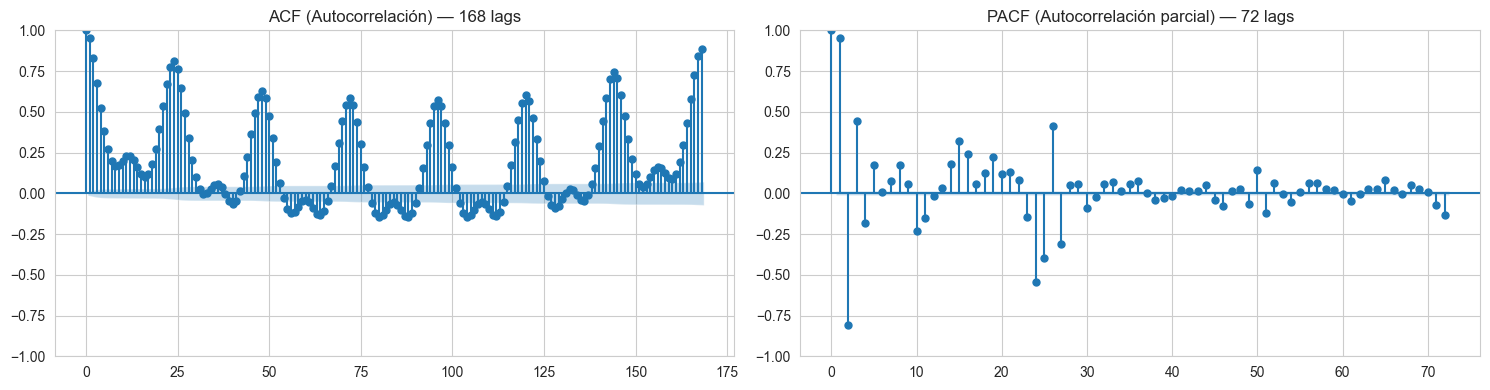

In [18]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Test ADF de estacionariedad
serie = df['demanda_mw'].values
adf = adfuller(serie, autolag='AIC')
print(f"Augmented Dickey-Fuller test:")
print(f"  Estadístico:  {adf[0]:.4f}")
print(f"  p-valor:      {adf[1]:.6f}")
print(f"  Valores críticos: {adf[4]}")
if adf[1] < 0.05:
    print(f"  → Serie ESTACIONARIA (p < 0.05)")
else:
    print(f"  → Serie NO estacionaria (p >= 0.05)")

# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie, lags=168, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF (Autocorrelación) — 168 lags')
plot_pacf(serie, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF (Autocorrelación parcial) — 72 lags')
plt.tight_layout()
plt.savefig('../../docs/capturas/08_acf_pacf.png', bbox_inches='tight')
plt.show()

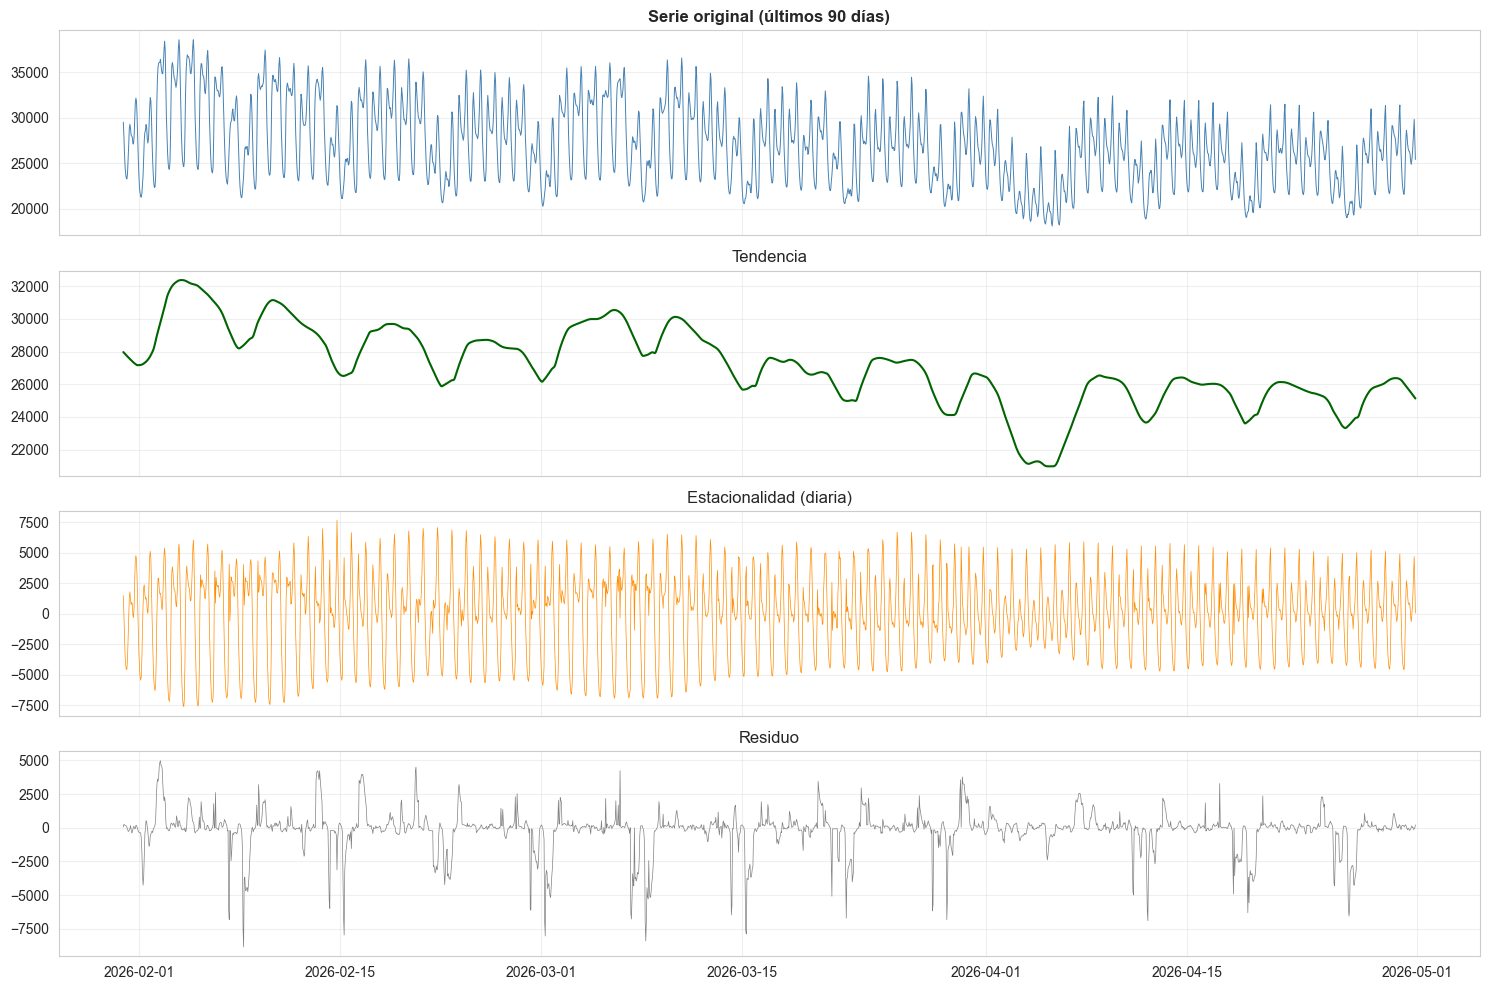

In [ ]:
from statsmodels.tsa.seasonal import STL

# Hacemos la descomposición sobre los últimos 90 días para que sea legible
df_idx = df.set_index('timestamp')
serie_90d = df_idx['demanda_mw'].iloc[-90*24:]  

stl = STL(serie_90d, period=24, robust=True)  
resultado = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(serie_90d.index, serie_90d.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Serie original (últimos 90 días)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[1].plot(resultado.trend.index, resultado.trend.values, color='darkgreen', linewidth=1.5)
axes[1].set_title('Tendencia')
axes[1].grid(True, alpha=0.3)
axes[2].plot(resultado.seasonal.index, resultado.seasonal.values, color='darkorange', linewidth=0.5)
axes[2].set_title('Estacionalidad (diaria)')
axes[2].grid(True, alpha=0.3)
axes[3].plot(resultado.resid.index, resultado.resid.values, color='gray', linewidth=0.5)
axes[3].set_title('Residuo')
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/09_stl.png', bbox_inches='tight')
plt.show()

In [20]:
print("="*60)
print("CONCLUSIONES DEL ANÁLISIS EXPLORATORIO")
print("="*60)
print()
print("ESTACIONALIDAD detectada:")
print("  - Diaria (24h):  pico mañana ~13h, pico noche ~21h")
print("  - Semanal (168h): laborales > fin de semana")
print("  - Anual (8760h): pico invierno + pico verano")
print()
print("PATRÓN APROVECHABLE POR EL LSTM:")
print("  - Ventana de entrada de 168h (7 días) capturará patrones diario+semanal")
print("  - Features de calendario (hora, día, mes, festivo) reforzarán al modelo")
print()
print(f"ESTACIONARIEDAD: la serie ES estacionaria (ADF p={adf[1]:.4f})")
print(f"  Esto significa que la media y varianza son estables en el tiempo,")
print(f"  condición necesaria para el ARIMA baseline.")
print()
print("RANGO DE LA VARIABLE OBJETIVO:")
print(f"  Min:    {df['demanda_mw'].min():.0f} MW  (madrugadas de Año Nuevo)")
print(f"  Media:  {df['demanda_mw'].mean():.0f} MW")
print(f"  Max:    {df['demanda_mw'].max():.0f} MW  (picos de verano/invierno)")
print("="*60)

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

ESTACIONALIDAD detectada:
  - Diaria (24h):  pico mañana ~13h, pico noche ~21h
  - Semanal (168h): laborales > fin de semana
  - Anual (8760h): pico invierno + pico verano

PATRÓN APROVECHABLE POR EL LSTM:
  - Ventana de entrada de 168h (7 días) capturará patrones diario+semanal
  - Features de calendario (hora, día, mes, festivo) reforzarán al modelo

ESTACIONARIEDAD: la serie ES estacionaria (ADF p=0.0000)
  Esto significa que la media y varianza son estables en el tiempo,
  condición necesaria para el ARIMA baseline.

RANGO DE LA VARIABLE OBJETIVO:
  Min:    16272 MW  (madrugadas de Año Nuevo)
  Media:  26933 MW
  Max:    41726 MW  (picos de verano/invierno)
